In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_adata(adata_to_plot, cluster_key, plot_type="umap", keyword=None):
    """
    Plot AnnData embeddings (UMAP or spatial).
    
    Parameters:
    - adata_to_plot: AnnData object with .obsm and .obs fields.
    - cluster_key: key in adata.obs to color by.
    - plot_type: "umap" or "spatial".
    - keyword: if provided, only highlight clusters containing this substring; others grouped as "Other".
    """

    # Prepare DataFrame for plotting
    if plot_type == "spatial":
        coords = adata_to_plot.obsm['spatial'].copy()
        df = pd.DataFrame(coords, columns=['x', 'y'], index=adata_to_plot.obs_names)
    else:  # UMAP
        df = pd.DataFrame(
            adata_to_plot.obsm['X_umap'],
            columns=['UMAP1', 'UMAP2'],
            index=adata_to_plot.obs_names
        )

    # Original cluster labels as strings
    df[cluster_key] = adata_to_plot.obs[cluster_key].astype(str)

    # If a keyword is provided, label matching clusters, others as "Other"
    if keyword:
        df['plot_label'] = df[cluster_key].apply(lambda x: x if keyword in x else 'Other')
        color_key = 'plot_label'
        legend_title = f"Highlighted: {keyword}"
    else:
        color_key = cluster_key
        legend_title = cluster_key

    # Get a discrete color map
    tab20 = [mpl.colors.rgb2hex(c) for c in plt.get_cmap('tab20').colors]

    # Choose appropriate scatter fields
    if plot_type == "spatial":
        fig = px.scatter(
            df,
            x='x',
            y='y',
            color=color_key,
            title='Spatial scatter — manual cell types',
            hover_name=df.index,
            width=1600,
            height=700
        )
        fig.update_traces(marker=dict(size=2, opacity=0.8))
        fig.update_yaxes(autorange='reversed')
    else:  # UMAP
        fig = px.scatter(
            df,
            x='UMAP1',
            y='UMAP2',
            color=color_key,
            title='UMAP embedding — Leiden clusters',
            color_discrete_sequence=tab20,
            hover_name=df.index,
            width=1400,
            height=1200
        )
        fig.update_traces(marker=dict(size=3, opacity=0.8))

    # Adjust legend and layout
    fig.update_layout(
        legend_title_text=legend_title,
        legend=dict(
            itemsizing='constant',
            traceorder='normal',
            bgcolor='rgba(255,255,255,0.5)',
            x=1.02,
            y=1
        ),
        margin=dict(l=20, r=200, t=50, b=20)
    )

    fig.show()

In [2]:
import scanpy as sc
import pandas as pd
import spatialdata



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/ugursahin/miniforge3/envs/ScanPy/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/ugursahin/miniforge3/envs/ScanPy/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/ugursahin/miniforge3/envs/ScanPy/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in

In [3]:
Tissue = "Region1"
TableFolder = "REGION1_TABLES"
in_out_path = f"/Volumes/ProstateCancerEvoMain/dbs/Ongoing/{Tissue}/{TableFolder}"

adata_xenium_p = f"{in_out_path}/{Tissue}_Xenium_Phen_HE_Integrated.Xenium_Process_Table.V2.All_Genes.h5ad"
adata = sc.read_h5ad(adata_xenium_p)
outfile = adata_xenium_p.replace(".V2",".Cell_Type_Annotated_Auto.V3.Majors")

adata_phen = sc.read_h5ad(f"/Volumes/ProstateCancerEvoMain/dbs/Ongoing/{Tissue}/{TableFolder}/{Tissue}_Xenium_Phen_HE_Integrated.Protein_PhenCycTable.V1.h5ad")


In [4]:
adata_phen.obs["cell_id"] = adata.obs["cell_id"].values
adata_phen.obs["cell_id"].index = adata.obs["cell_id"].index
adata_phen.obs_names = adata.obs_names

In [5]:
#plot_adata(adata, "leiden")

In [6]:
#plot_adata(adata, "leiden", plot_type="spatial")

In [7]:
# leiden_counts = adata.obs["leiden"].value_counts()

# small_clusters = leiden_counts[leiden_counts < 900].index.tolist()
# adata.obs["leiden"] = adata.obs["leiden"].astype(str)
# adata.obs.loc[adata.obs["leiden"].isin(small_clusters), "leiden"] = "-1"
# adata.obs["leiden"].value_counts()

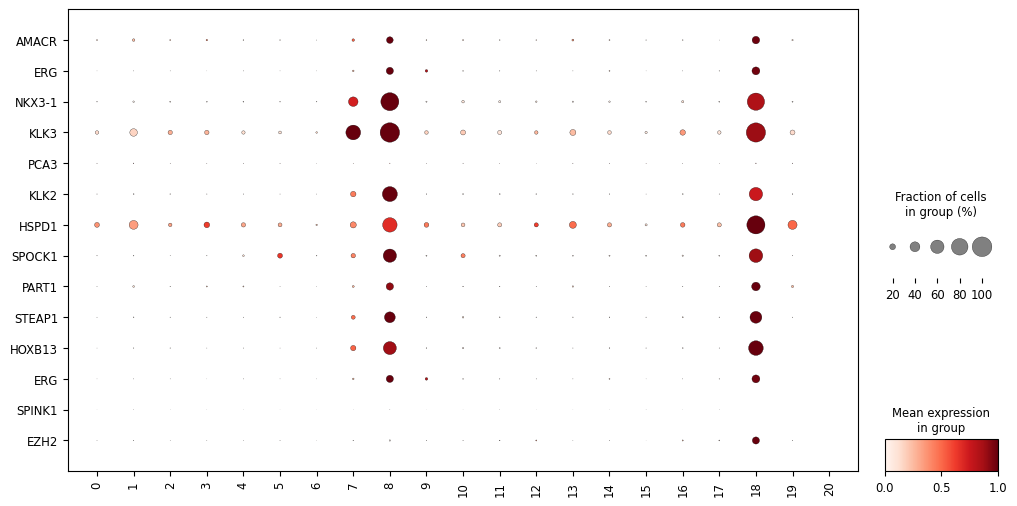

In [8]:
tumor_cell_markers = ["AMACR","ERG","NKX3-1","KLK3","PCA3","PSMA","PSCA","KLK2","SHNG15","HSPD1","SPOCK1","PART1","STEAP1" ,"HOXB13","PSCA","AGR2","ERG","SPINK1","EZH2"]



present = [g for g in tumor_cell_markers if g in list(adata.var_names)]

# Create the dotplot
sc.pl.dotplot(
    adata,
    present,
    groupby="leiden",
    standard_scale='var',   # scale each gene to [0,1] across groups
    swap_axes=True,
    dendrogram=False,
    dot_max=1,
    figsize=(12, 6),
)


In [9]:
import os
import pandas as pd
from scipy import sparse

cluster_key = "leiden"

target_ann_folder_path = "/Users/ugursahin/Downloads/ProstateAnnMajor"
annotation_files       = [
    f for f in os.listdir(target_ann_folder_path)
    if f.lower().endswith(".csv")
]

# Dict to accumulate per-cell-type totals
totals_dict = {}

for fname in annotation_files:
    cell_type_name = os.path.splitext(fname)[0]
    file_path      = os.path.join(target_ann_folder_path, fname)
    
    # Read gene list
    annotation_df    = pd.read_csv(file_path, header=None)
    genes_of_interest = annotation_df[0].tolist()
    
    # Filter and extract expression
    present = [g for g in genes_of_interest if g in adata.var_names]
    X       = adata[:, present].X
    if sparse.issparse(X):
        X = X.toarray()
    
    # Build DataFrame and sum
    df               = pd.DataFrame(X, index=adata.obs_names, columns=present)
    df[cluster_key]     = adata.obs[cluster_key].values
    sum_per_gene     = df.groupby(cluster_key)[present].sum()
    total_per_cluster = sum_per_gene.sum(axis=1)
    
    # Store the Series
    totals_dict[cell_type_name] = total_per_cluster



#extras = {"tumor_cell_markers":["AMACR","ERG","NKX3-1","KLK3","PCA3","PSMA","NKX3-1","HOXB13","PSCA","AGR2","ERG","SPINK1","EZH2"],"neuron_cells":["VIM", "MPZ", "CSN7A","PMP22","CLIC4", "AHR", "AQP7"]}
extras ={}
for k,v in extras.items():
    cell_type_name = k
    genes_of_interest = v
    
    # Filter and extract expression
    present = [g for g in genes_of_interest if g in adata.var_names]
    X       = adata[:, present].X
    if sparse.issparse(X):
        X = X.toarray()
    
    # Build DataFrame and sum
    df               = pd.DataFrame(X, index=adata.obs_names, columns=present)
    df[cluster_key]     = adata.obs[cluster_key].values
    sum_per_gene     = df.groupby(cluster_key)[present].sum()
    total_per_cluster = sum_per_gene.sum(axis=1)
    
    totals_dict[cell_type_name] = total_per_cluster


# Concatenate all into one DataFrame (clusters×cell_types)
totals_df = pd.concat(totals_dict, axis=1)

# totals_df now has:
#   index = leiden clusters
#   columns = each cell_type_name
#   values = summed expression of that cell type’s gene list per cluster

totals_df.T

/var/folders/4p/7h_929nx5qngrf9z7xhfy15w0000gn/T/ipykernel_21136/3172435113.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sum_per_gene     = df.groupby(cluster_key)[present].sum()
/var/folders/4p/7h_929nx5qngrf9z7xhfy15w0000gn/T/ipykernel_21136/3172435113.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sum_per_gene     = df.groupby(cluster_key)[present].sum()
/var/folders/4p/7h_929nx5qngrf9z7xhfy15w0000gn/T/ipykernel_21136/3172435113.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current beh

leiden,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
epithelialcellofprostate,8219.499023,48259.070312,-15558.605469,2415.288574,-28584.888672,-21010.726562,-30126.277344,16813.664062,71544.398438,-18892.451172,...,-14903.618164,-14892.338867,7146.125000,-10230.588867,-6912.384277,-5320.640137,-3124.770996,3771.692871,116.309830,-757.677246
hematopoieticcell,-47017.484375,-16360.831055,-59273.843750,-43663.910156,-39237.757812,-33141.507812,-52752.734375,-38665.750000,-8258.912109,-20109.146484,...,124290.757812,130321.343750,-11780.331055,-13565.969727,-9630.259766,12141.255859,19422.953125,619.964539,61.668243,-1340.607544
mesenchymalcell,-44737.277344,-46672.441406,-47022.105469,-44781.480469,64502.839844,86930.640625,-20274.798828,-25205.234375,-9146.727539,-4737.344727,...,-3039.580811,-8886.971680,-17507.046875,7509.918457,-3313.444336,-1141.213623,-1765.433838,1271.802246,-486.415314,-859.626343
mesenchymalstemcell,-39668.464844,-30900.949219,-47906.003906,-37005.582031,77339.554688,91367.859375,-25467.830078,-29557.814453,-7625.503906,14021.671875,...,-6591.121094,-11749.428711,-13506.787109,16015.427734,2512.784668,-3297.034668,-2053.020020,-93.329010,-408.215302,-914.864746


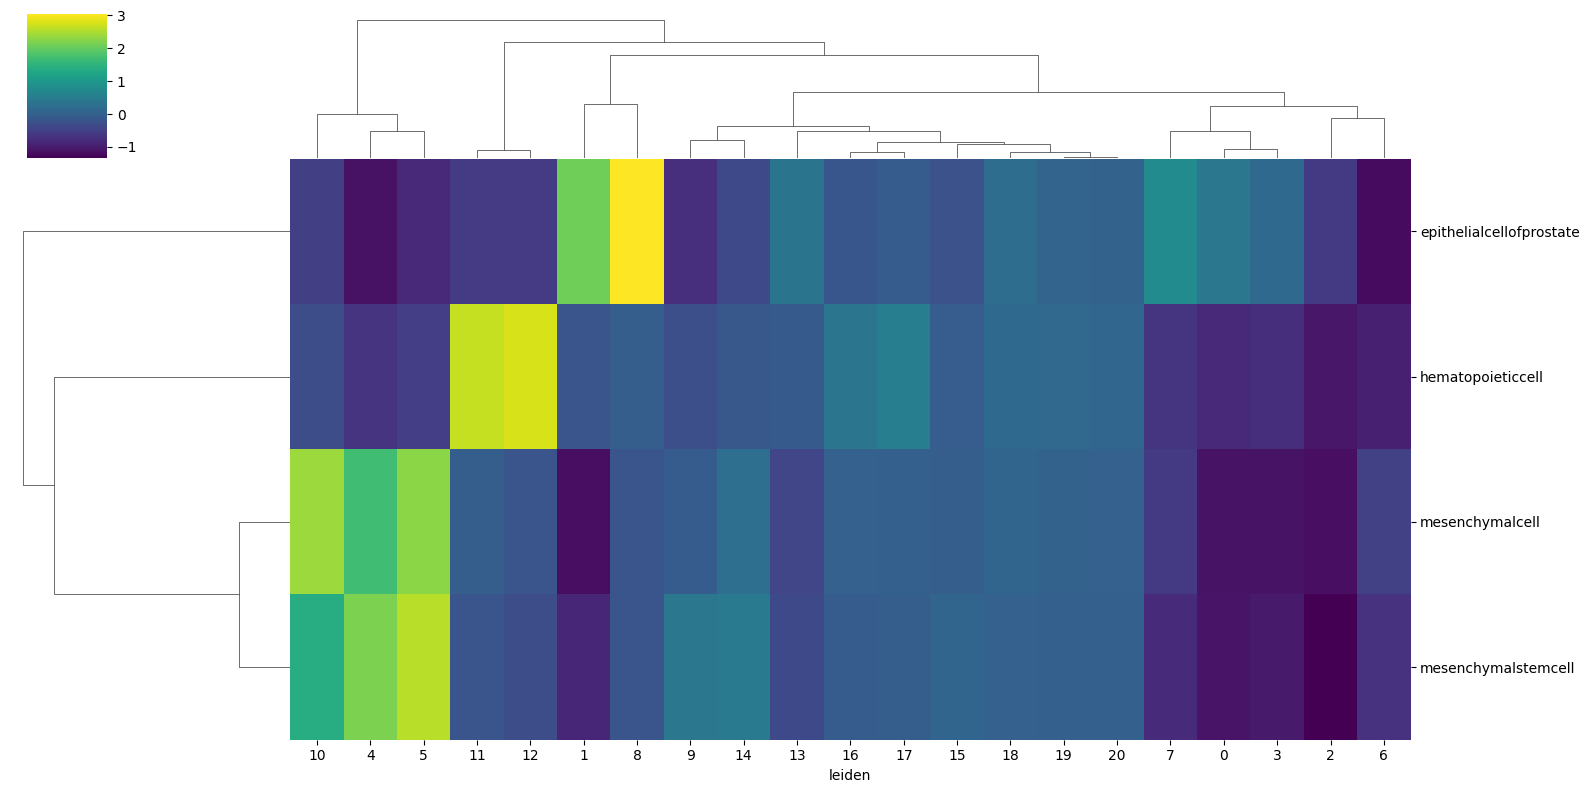

In [10]:
import seaborn as sns


df_t = totals_df.T
standardized = df_t.sub(df_t.mean(axis=1), axis=0).div(df_t.std(axis=1), axis=0)

#standardized[standardized < 0] = -2


sns.clustermap(standardized,
               metric='euclidean',
               method='average',
               cmap='viridis',
               figsize=(16,8))




In [11]:
standardized = df_t.sub(df_t.mean(axis=1), axis=0).div(df_t.std(axis=1), axis=0)

In [12]:
# For each cluster, a list of its standardized scores sorted descending
sorted_vals = {
    col: standardized[col]
             .sort_values(ascending=False)
             .values
             .tolist()
    for col in standardized.columns
}

# If you prefer a DataFrame where each column is sorted scores:
import pandas as pd
sorted_vals_df = pd.DataFrame({
    col: standardized[col].sort_values(ascending=False).values
    for col in standardized.columns
})

sorted_df_t = sorted_vals_df.T
#sorted_df_t[sorted_df_t[0] > 0.5 ]


In [13]:
import pandas as pd

# `standardized` is your DataFrame with
# index = cell_type_name, columns = leiden clusters

# Build a dict: for each cluster, a list of cell types sorted by descending value
sorted_idx = {
    col: standardized[col]
            .sort_values(ascending=False)
            .index
            .tolist()
    for col in standardized.columns
}

# Turn that into a DataFrame
sorted_names_df = pd.DataFrame(sorted_idx)

# Now `sorted_names_df` has:
#   index = rank (0 = highest), 1, 2, …  
#   columns = each leiden cluster  
#   values = cell_type_name in descending order of standardized score

sorted_names_df.T


,0,1,2,3
0,epithelialcellofprostate,hematopoieticcell,mesenchymalstemcell,mesenchymalcell
1,epithelialcellofprostate,hematopoieticcell,mesenchymalstemcell,mesenchymalcell
2,epithelialcellofprostate,hematopoieticcell,mesenchymalcell,mesenchymalstemcell
3,epithelialcellofprostate,hematopoieticcell,mesenchymalstemcell,mesenchymalcell
4,mesenchymalstemcell,mesenchymalcell,hematopoieticcell,epithelialcellofprostate
5,mesenchymalstemcell,mesenchymalcell,hematopoieticcell,epithelialcellofprostate
6,mesenchymalcell,mesenchymalstemcell,hematopoieticcell,epithelialcellofprostate
7,epithelialcellofprostate,mesenchymalcell,hematopoieticcell,mesenchymalstemcell
8,epithelialcellofprostate,hematopoieticcell,mesenchymalcell,mesenchymalstemcell
9,mesenchymalstemcell,mesenchymalcell,hematopoieticcell,epithelialcellofprostate


In [14]:
import numpy as np
# Get integer positions of those rows
positions = np.where(sorted_df_t[0] > 0)[0]
subset_df_iloc = sorted_names_df.T.iloc[positions]
subset_df_iloc



,0,1,2,3
0,epithelialcellofprostate,hematopoieticcell,mesenchymalstemcell,mesenchymalcell
1,epithelialcellofprostate,hematopoieticcell,mesenchymalstemcell,mesenchymalcell
3,epithelialcellofprostate,hematopoieticcell,mesenchymalstemcell,mesenchymalcell
4,mesenchymalstemcell,mesenchymalcell,hematopoieticcell,epithelialcellofprostate
5,mesenchymalstemcell,mesenchymalcell,hematopoieticcell,epithelialcellofprostate
7,epithelialcellofprostate,mesenchymalcell,hematopoieticcell,mesenchymalstemcell
8,epithelialcellofprostate,hematopoieticcell,mesenchymalcell,mesenchymalstemcell
9,mesenchymalstemcell,mesenchymalcell,hematopoieticcell,epithelialcellofprostate
10,mesenchymalcell,mesenchymalstemcell,hematopoieticcell,epithelialcellofprostate
11,hematopoieticcell,mesenchymalcell,mesenchymalstemcell,epithelialcellofprostate


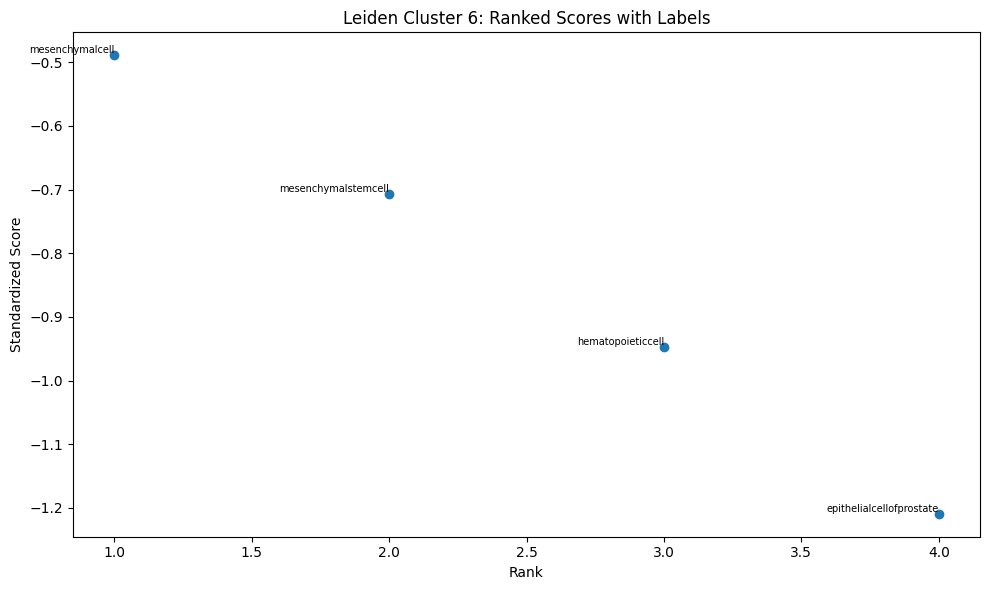

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1. (Re)compute the z-scored DataFrame
df_t = totals_df.T
standardized = df_t.sub(df_t.mean(axis=1), axis=0).div(df_t.std(axis=1), axis=0)

leiden_group = "6"
# 2. Extract cluster “6” and sort
series = standardized[leiden_group].sort_values(ascending=False)
scores = series.values
ranks = np.arange(1, len(scores) + 1)
names = series.index


# 4. Plot with labels
plt.figure(figsize=(10, 6))   # Was default, now increased
plt.scatter(ranks, scores)
for x, y, label in zip(ranks, scores, names):
    plt.text(x, y, label, fontsize=7, ha='right', va='bottom')

plt.xlabel('Rank')
plt.ylabel('Standardized Score')
plt.title(f"Leiden Cluster {leiden_group}: Ranked Scores with Labels")
plt.tight_layout()
plt.show()

In [16]:
# 1) Duplicate the leiden labels
adata.obs["major_cell_type_xenium_panel"] = adata.obs[cluster_key].astype(str)

# 2) Build a dict mapping original leiden → new label
#    (uses the DataFrame's index as the key, and its first column as the value)
mapping = subset_df_iloc.iloc[:, 0].to_dict()

# 3) Apply the mapping: leave all other clusters unchanged
adata.obs["major_cell_type_xenium_panel"] = (
    adata.obs["major_cell_type_xenium_panel"]
        .map(mapping)
        .fillna(adata.obs["major_cell_type_xenium_panel"])
)

In [17]:
#plot_adata(adata, cluster_key="major_cell_type_xenium_panel", plot_type="umap")

In [18]:
plot_adata(adata, cluster_key="leiden", plot_type="umap")

In [19]:
# plot_adata(adata, cluster_key="leiden", plot_type="spatial")

In [20]:
adata

AnnData object with n_obs × n_vars = 113273 × 5101
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'leiden', 'cell_type', 'major_cell_type_xenium_panel'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_leiden', 'spatialdata_attrs', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [21]:
if Tissue == "Region4":
    adata.obs.loc[adata.obs["leiden"] == "1", "major_cell_type_xenium_panel"] = "epithelialcellofprostate"
    adata.obs.loc[adata.obs["leiden"] == "3", "major_cell_type_xenium_panel"] = "progenitor_like"



In [22]:
if Tissue == "Region3":
    adata.obs.loc[adata.obs["leiden"] == "17", "major_cell_type_xenium_panel"] = "epithelialcellofprostate"
    adata.obs.loc[adata.obs["leiden"] == "13", "major_cell_type_xenium_panel"] = "epithelialcellofprostate"
    adata.obs.loc[adata.obs["leiden"] == "4", "major_cell_type_xenium_panel"] = "progenitor_like"
    adata.obs.loc[adata.obs["leiden"] == "16", "major_cell_type_xenium_panel"] = "Unknown"
    adata.obs.loc[adata.obs["leiden"] == "14", "major_cell_type_xenium_panel"] = "epithelialcellofprostate"
    adata.obs.loc[adata.obs["leiden"] == "1", "major_cell_type_xenium_panel"] = "epithelialcellofprostate"



In [23]:
if Tissue == "Region2":
    adata.obs.loc[adata.obs["leiden"] == "9", "major_cell_type_xenium_panel"] = "progenitor_like"
    adata.obs.loc[adata.obs["leiden"] == "13", "major_cell_type_xenium_panel"] = "progenitor_like"
    adata.obs.loc[adata.obs["leiden"] == "4", "major_cell_type_xenium_panel"] = "epithelialcellofprostate"



In [24]:
if Tissue == "Region1":
    adata.obs.loc[adata.obs["leiden"] == "2", "major_cell_type_xenium_panel"] = "epithelialcellofprostate"
    adata.obs.loc[adata.obs["leiden"] == "6", "major_cell_type_xenium_panel"] = "mesenchymalstemcell"
    adata.obs.loc[adata.obs["leiden"] == "1", "major_cell_type_xenium_panel"] = "epithelialcellofprostate"




In [25]:
plot_adata(adata, cluster_key="major_cell_type_xenium_panel", plot_type="umap")

## For Immune Cells

In [26]:
adata_phen.obs_names

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '113263', '113264', '113265', '113266', '113267', '113268', '113269',
       '113270', '113271', '113272'],
      dtype='object', length=113273)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/ugursahin/miniforge3/envs/ScanPy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

/var/folders/4p/7h_929nx5qngrf9z7xhfy15w0000gn/T/ipykernel_21136/924891580.py:8: FutureWarning:

In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.



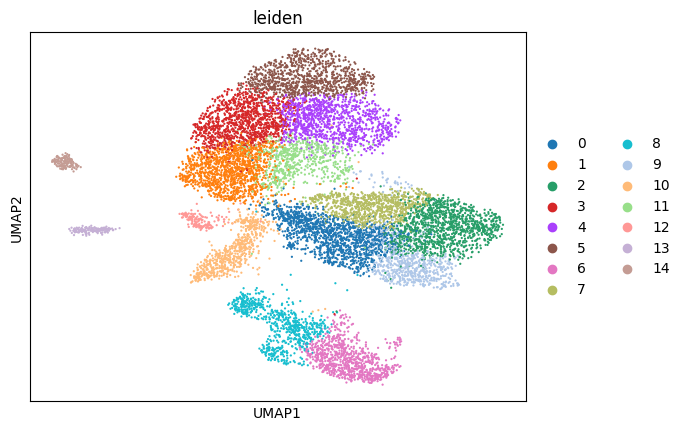

In [ ]:
## Immune Cell Section

keep_celltypes = ["hematopoieticcell"]
mask = adata.obs["major_cell_type_xenium_panel"].isin(keep_celltypes)
adata_immune = adata[mask].copy()

sc.pp.neighbors(adata_immune, n_neighbors=15, n_pcs=40)
sc.tl.leiden(adata_immune, resolution=1.0, key_added="leiden")
sc.tl.umap(adata_immune)
sc.pl.umap(adata_immune, color="leiden")

adata_immune.write_h5ad(f"/Volumes/ProstateCancerEvoMain/dbs/Ongoing/Collection/MajorAnnGroups/ImmuneAnn_SubTypes/{Tissue}.ImmuneAnn_SubTypes.h5ad")


common_cells = adata_immune.obs_names.intersection(adata_phen.obs_names)
adata_phen_immune = adata_phen[common_cells].copy()

adata_phen_immune
adata_phen_immune.obs["cell_id"] = adata_immune.obs["cell_id"].values

adata_phen_immune.write_h5ad(f"/Volumes/ProstateCancerEvoMain/dbs/Ongoing/Collection/MajorAnnGroups/ImmuneAnn_SubTypes/{Tissue}.ImmuneAnn_SubTypes.PhenCyc.h5ad")


## For Mesenchymal Cells

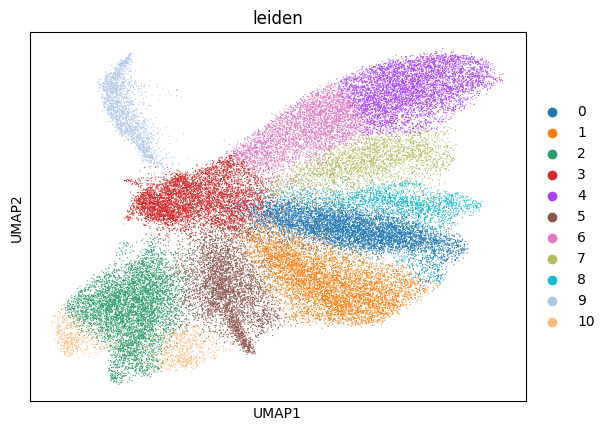

In [ ]:

keep_celltypes = ["mesenchymalcell", "mesenchymalstemcell"]
mask = adata.obs["major_cell_type_xenium_panel"].isin(keep_celltypes)
adata_mesen = adata[mask].copy()

sc.pp.neighbors(adata_mesen, n_neighbors=15, n_pcs=40)
sc.tl.leiden(adata_mesen, resolution=1.0, key_added="leiden")
sc.tl.umap(adata_mesen)
sc.pl.umap(adata_mesen, color="leiden")

adata_mesen.write_h5ad(f"/Volumes/ProstateCancerEvoMain/dbs/Ongoing/Collection/MajorAnnGroups/Mesenchymal_Subtypes/{Tissue}.Mesenchymal_Subtypes.h5ad")


common_cells = adata_mesen.obs_names.intersection(adata_phen.obs_names)
adata_phen_mesen = adata_phen[common_cells].copy()

adata_phen_mesen.obs["cell_id"] = adata_mesen.obs["cell_id"].values
adata_phen_mesen.write_h5ad(f"/Volumes/ProstateCancerEvoMain/dbs/Ongoing/Collection/MajorAnnGroups/Mesenchymal_Subtypes/{Tissue}.Mesenchymal_Subtypes.PhenCyc.h5ad")



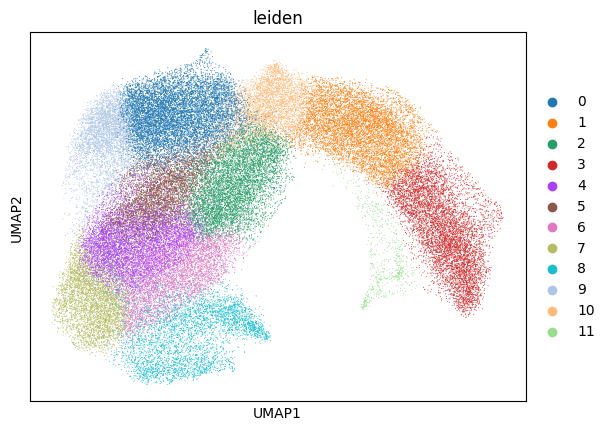

In [ ]:
keep_celltypes = ["epithelialcellofprostate"]
mask = adata.obs["major_cell_type_xenium_panel"].isin(keep_celltypes)
adata_epithelia = adata[mask].copy()

sc.pp.neighbors(adata_epithelia, n_neighbors=15, n_pcs=40)
sc.tl.leiden(adata_epithelia, resolution=1.0, key_added="leiden")
sc.tl.umap(adata_epithelia)
sc.pl.umap(adata_epithelia, color="leiden")

adata_epithelia.write_h5ad(f"/Volumes/ProstateCancerEvoMain/dbs/Ongoing/Collection/MajorAnnGroups/Epithelia_SubTypes/{Tissue}.Epithelia_SubTypes.h5ad")


common_cells = adata_epithelia.obs_names.intersection(adata_phen.obs_names)
adata_phen_epit = adata_phen[common_cells].copy()

adata_phen_epit.obs["cell_id"] = adata_epithelia.obs["cell_id"].values
adata_phen_epit.write_h5ad(f"/Volumes/ProstateCancerEvoMain/dbs/Ongoing/Collection/MajorAnnGroups/Epithelia_SubTypes/{Tissue}.Epithelia_SubTypes.PhenCyc.h5ad")

In [30]:
# ## Record the Cell Markers used ! 

# # 1) Duplicate the leiden labels
# adata.obs["cell_type_xenium_panel_not_confident"] = adata.obs[cluster_key].astype(str)

# # 2) Build a dict mapping original leiden → new label
# #    (uses the DataFrame's index as the key, and its first column as the value)
# mapping = subset_df_iloc.iloc[:, 0].to_dict()

# # 3) Apply the mapping: leave all other clusters unchanged
# adata.obs["cell_type_xenium_panel"] = (
#     adata.obs["cell_type_xenium_panel"]
#         .map(mapping)
#         .fillna(adata.obs["cell_type_xenium_panel"])
# )

In [ ]:
#adata.write_h5ad(outfile)

## Further Extracting Names

In [ ]:
# import os
# import pandas as pd
# from scipy import sparse

# target_ann_folder_path = "/Volumes/ProstateCancerEvoMain/dbs/Ongoing/Collection/MajorAnnGroups/ImmuneAnn_SubTypes"
# annotation_files       = [
#     f for f in os.listdir(target_ann_folder_path)
#     if f.lower().endswith(".csv")
# ]

# # Dicts to accumulate results
# totals_dict  = {}
# markers_dict = {}

# for fname in annotation_files:
#     cell_type_name = os.path.splitext(fname)[0]
#     file_path      = os.path.join(target_ann_folder_path, fname)
    
#     # Read gene list
#     annotation_df    = pd.read_csv(file_path, header=None)
#     genes_of_interest = annotation_df[0].tolist()
    
#     # Filter to those actually in adata
#     present = [g for g in genes_of_interest if g in adata.var_names]
    
#     # Store the markers list
#     markers_dict[cell_type_name] = present



In [ ]:
# import os
# import pandas as pd

# # 1. Folder with your annotation CSVs
# target_ann_folder_path = "/Volumes/ProstateCancerEvoMain/dbs/Ongoing/Collection/MajorAnnGroups/ImmuneAnn_SubTypes"

# # 2. Collect all .csv filenames
# annotation_files = [
#     f for f in os.listdir(target_ann_folder_path)
#     if f.lower().endswith(".csv")
# ]

# # 3. Build records list
# records = []
# for fname in annotation_files:
#     cell_type_name = os.path.splitext(fname)[0]
#     # Read the raw list of genes
#     df = pd.read_csv(os.path.join(target_ann_folder_path, fname), header=None)
#     genes = df[0].astype(str).tolist()
#     # Append the row dict
#     records.append({
#         'tissueType': 'Prostate',
#         'cellName': cell_type_name,
#         'geneSymbolmore1': ','.join(genes),
#         'geneSymbolmore2': '',
#         'shortName': cell_type_name
#     })

# # 4. Create DataFrame with the exact column order and headers
# out_df = pd.DataFrame(
#     records,
#     columns=[
#         'tissueType',
#         'cellName',
#         'geneSymbolmore1',
#         'geneSymbolmore2',
#         'shortName'
#     ]
# )

# # 5. Save to Excel
# output_path = '/Volumes/ProstateCancerEvoMain/dbs/Ongoing/Collection/MajorAnnGroups/ImmuneAnn_SubTypes/ImmuneAnn_SubTypes.V1.xlsx'
# out_df.to_excel(output_path, index=False)

# print(f"Written Excel file to {output_path}")

In [34]:
# sc.tl.rank_genes_groups(adata_immune, n_genes=10, groupby="leiden", sharey=False)


In [35]:
#sc.pl.rank_genes_groups(adata_immune, n_genes=10, groupby="leiden", sharey=False)
